# Baseline Model Walkthrough

This notebook reproduces the baseline metadata model results from `src/baseline_model.py` and makes them visible through tables and plots.

What it covers:
- human-only supervised training rows
- grouped validation by human nickname
- baseline model comparison
- fold-wise RMSE and MAE
- boosting training and validation loss curve
- sample predictions for the test set

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from src.baseline_model import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    build_folded_train_frame,
    load_test_frame,
    make_model_pipelines,
)

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")

## 1. Load The Baseline Dataset

The supervised unit is one human player in one game against one bot. The folds come from `src/validation.py`, so the validation here matches the baseline report.

In [2]:
train_frame = build_folded_train_frame(n_splits=5, seed=42)
test_frame = load_test_frame()

print('Train rows:', len(train_frame))
print('Test rows:', len(test_frame))
print('Train columns:', sorted(train_frame.columns.tolist()))

train_frame.head()

Train rows: 50410
Test rows: 22363
Train columns: ['bot_nickname', 'bot_rating', 'bot_score', 'created_at', 'first', 'first_is_bot', 'fold', 'game_duration_seconds', 'game_end_reason', 'game_id', 'human_nickname', 'human_rating', 'human_score', 'increment_seconds', 'initial_time_seconds', 'lexicon', 'max_overtime_minutes', 'rating_mode', 'score_diff', 'score_total', 'time_control_name', 'winner']


,game_id,human_nickname,human_rating,human_score,bot_nickname,bot_rating,bot_score,first,time_control_name,game_end_reason,winner,created_at,lexicon,initial_time_seconds,increment_seconds,rating_mode,max_overtime_minutes,game_duration_seconds,score_diff,score_total,first_is_bot,fold
0,1,stevy,"1,500.0000",429.0000,BetterBot,"1,637.0000",335.0000,BetterBot,regular,STANDARD,1,2022-08-26 03:38:49,NWL20,1200,0,CASUAL,1,674.8443,94.0000,764.0000,1.0000,1
1,3,davidavid,"1,811.0000",440.0000,BetterBot,"2,071.0000",318.0000,BetterBot,regular,STANDARD,1,2022-09-04 08:04:27,CSW21,900,0,RATED,5,492.2683,122.0000,758.0000,1.0000,1
2,4,Inandoutworker,"1,473.0000",119.0000,BetterBot,"1,936.0000",478.0000,BetterBot,regular,RESIGNED,0,2022-09-12 02:36:19,CSW21,3600,0,CASUAL,1,350.8611,-359.0000,597.0000,1.0000,2
3,5,stevy,"1,500.0000",325.0000,STEEBot,"1,844.0000",427.0000,STEEBot,regular,STANDARD,0,2022-09-06 04:31:36,NWL20,1200,0,CASUAL,1,642.6887,-102.0000,752.0000,1.0000,1
4,6,HivinD,"2,029.0000",378.0000,STEEBot,"2,143.0000",427.0000,HivinD,regular,STANDARD,0,2022-08-21 14:56:35,CSW21,900,0,RATED,1,426.9505,-49.0000,805.0000,0.0000,3


## 2. Fold Balance

In [3]:
fold_summary = (
    train_frame.groupby('fold')
    .agg(
        rows=('game_id', 'size'),
        unique_humans=('human_nickname', 'nunique'),
        avg_rating=('human_rating', 'mean'),
        avg_score=('human_score', 'mean'),
    )
    .reset_index()
)
fold_summary

,fold,rows,unique_humans,avg_rating,avg_score
0,0,10082,187,"1,599.0186",375.9462
1,1,10082,209,"1,805.9548",369.5790
2,2,10082,210,"1,864.8705",378.5800
3,3,10082,211,"1,844.0198",379.8005
4,4,10082,211,"1,837.7497",376.3978


## 3. Model Evaluation Helpers

In [ ]:
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

def evaluate_models_verbose(frame, n_splits=5):
    models = make_model_pipelines()
    # summary_rows = []
    fold_rows = []
    fitted_models = {}

    for model_name, model in models.items():
        fitted_models[model_name] = []
        for fold in range(n_splits):
            train_fold = frame[frame['fold'] != fold]
            valid_fold = frame[frame['fold'] == fold]

            x_train = train_fold[FEATURES]
            y_train = train_fold['human_rating']
            x_valid = valid_fold[FEATURES]
            y_valid = valid_fold['human_rating']

            model.fit(x_train, y_train)
            preds = model.predict(x_valid)

            fold_rows.append({
                'model': model_name,
                'fold': fold,
                'rmse': float(root_mean_squared_error(y_valid, preds)),
                'mae': float(mean_absolute_error(y_valid, preds)),
            })
            fitted_models[model_name].append(model)

    fold_df = pd.DataFrame(fold_rows)
    summary_df = (
        fold_df.groupby('model')[['rmse', 'mae']]
        .mean()
        .sort_values('rmse')
        .reset_index()
        .rename(columns={'rmse': 'avg_rmse', 'mae': 'avg_mae'})
    )
    return summary_df, fold_df, fitted_models

summary_df, fold_df, fitted_models = evaluate_models_verbose(train_frame)
summary_df

,model,avg_rmse,avg_mae
0,ridge_onehot,147.2317,112.0614
1,hist_gbm,157.0773,122.7128
2,global_mean,238.8272,208.1407


## 4. Average Validation Performance

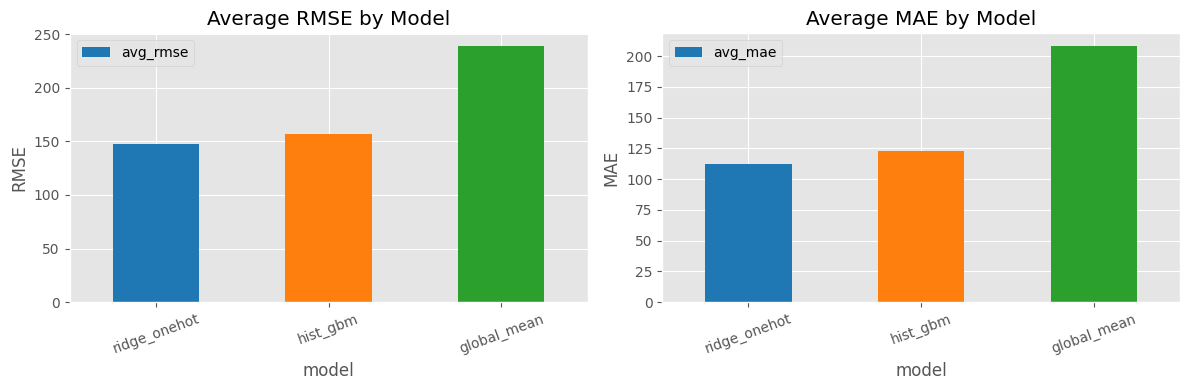

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_df.plot.bar(x='model', y='avg_rmse', ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Average RMSE by Model')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

summary_df.plot.bar(x='model', y='avg_mae', ax=axes[1], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Average MAE by Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Fold-Wise Metrics

In [6]:
pivot_rmse = fold_df.pivot(index='fold', columns='model', values='rmse')
pivot_mae = fold_df.pivot(index='fold', columns='model', values='mae')

print('Fold-wise RMSE')
display(pivot_rmse)
print('Fold-wise MAE')
display(pivot_mae)

Fold-wise RMSE


model,global_mean,hist_gbm,ridge_onehot
fold,,,
0,303.4369,123.5335,120.2585
1,225.2836,195.3789,161.4775
2,224.5286,143.8152,149.8568
3,216.8992,161.6679,148.1997
4,223.9878,160.9908,156.3660


Fold-wise MAE


model,global_mean,hist_gbm,ridge_onehot
fold,,,
0,280.2139,98.8207,87.5960
1,189.2563,153.1396,127.8221
2,195.5993,107.9268,107.8489
3,184.9842,127.0585,117.6819
4,190.6497,126.6183,119.3582


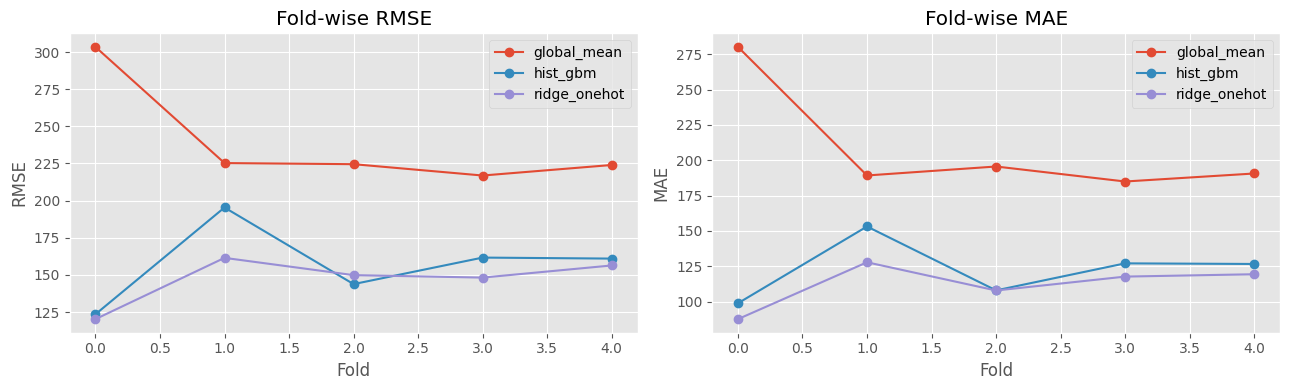

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model_name in pivot_rmse.columns:
    axes[0].plot(pivot_rmse.index, pivot_rmse[model_name], marker='o', label=model_name)
axes[0].set_title('Fold-wise RMSE')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].legend()

for model_name in pivot_mae.columns:
    axes[1].plot(pivot_mae.index, pivot_mae[model_name], marker='o', label=model_name)
axes[1].set_title('Fold-wise MAE')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. HistGradientBoosting Training Curve

For regression, the main quality metrics are RMSE and MAE, not classification accuracy. To make training dynamics visible, this section shows the boosting model's internal training and validation scores over iterations on one fold.

In [8]:
hist_model = make_model_pipelines()['hist_gbm']
train_fold = train_frame[train_frame['fold'] != 0]
valid_fold = train_frame[train_frame['fold'] == 0]

x_train = train_fold[FEATURES]
y_train = train_fold['human_rating']
x_valid = valid_fold[FEATURES]
y_valid = valid_fold['human_rating']

hist_model.fit(x_train, y_train)
valid_preds = hist_model.predict(x_valid)
print('Fold 0 validation RMSE:', round(root_mean_squared_error(y_valid, valid_preds), 4))
print('Fold 0 validation MAE:', round(mean_absolute_error(y_valid, valid_preds), 4))

booster = hist_model.named_steps['model']
curve_df = pd.DataFrame({
    'iteration': range(len(booster.train_score_)),
    'train_score': booster.train_score_,
    'validation_score': booster.validation_score_,
})
curve_df.head()

Fold 0 validation RMSE: 123.5335
Fold 0 validation MAE: 98.8207


,iteration,train_score,validation_score
0,0,"-22,863.2494","-23,083.8442"
1,1,"-21,374.1881","-21,575.2745"
2,2,"-20,053.5164","-20,245.2351"
3,3,"-18,884.9559","-19,061.8783"
4,4,"-17,846.1363","-18,004.2635"


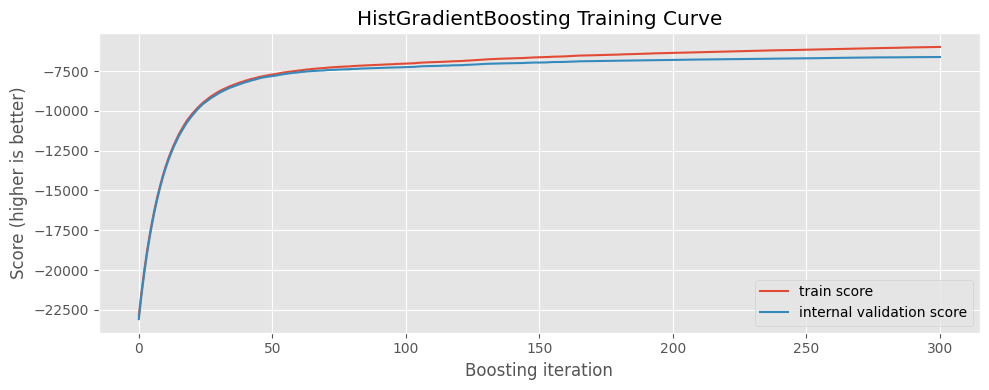

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(curve_df['iteration'], curve_df['train_score'], label='train score')
ax.plot(curve_df['iteration'], curve_df['validation_score'], label='internal validation score')
ax.set_title('HistGradientBoosting Training Curve')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('Score (higher is better)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Sample Test Predictions From The Best Baseline

In [10]:
best_model_name = summary_df.iloc[0]['model']
best_model = make_model_pipelines()[best_model_name]
best_model.fit(train_frame[FEATURES], train_frame['human_rating'])

test_preview = test_frame[['game_id', 'human_nickname']].head(10).copy()
test_preview['predicted_rating'] = best_model.predict(test_frame[FEATURES].head(10))
test_preview

,game_id,human_nickname,predicted_rating
0,2,Super,"2,023.9274"
1,7,Priya1,"1,954.6253"
2,11,TileRunner,"1,686.4815"
3,14,Anfield223,"1,959.4296"
4,27,friesbasil,"2,058.1147"
5,28,Eloquent,"1,893.6958"
6,32,Super,"2,030.9190"
7,40,eugenius,"1,659.6702"
8,41,marvin,"1,684.7092"
9,44,jlevedit,"1,688.1332"
